In [133]:
import requests
import pandas as pd
from IPython.display import display
from io import StringIO
from dstapi import DstApi 

# Stratification Frame
The purpose of this notebook is to download, clean and combine the datasets into one stratification frame for Denmark.

In [134]:
# FOLK1D is the population table that will be the basis for the raking
pop_api = DstApi('FOLK1D')

# View summary of education table
pop_api.tablesummary(language='en')


KeyboardInterrupt: 

In [ ]:
# Generate template
params = pop_api.define_base_params(language='en')
for var in params['variables']:
    if var['code'] == 'KVARTAL':
        var['values'] = ['2026Q1'] # only for 2024

df = pop_api.get_data(params=params)
df.head()



,OMRÅDE,KØN,ALDER,STATSB,TID,INDHOLD
0,Region Midtjylland,Total,91 years,Danish citizen,2022Q4,1813
1,Region Midtjylland,Total,91 years,Total,2022Q4,1839
2,Region Midtjylland,Total,91 years,Foreign citizen,2022Q4,26
3,Region Midtjylland,Total,92 years,Danish citizen,2022Q4,1528
4,Region Midtjylland,Total,92 years,Total,2022Q4,1546


In [55]:
# recode columns
df.rename(columns={'INDHOLD': 'N', 'ALDER': 'age', 'OMRÅDE': 'municipality','KØN':'gender', 'STATSB':'citizenship'}, inplace=True)
print(len(df.index))

# regions to remove
regions_to_remove = ['Region Hovedstaden', 'Region Midtjylland', 'Region Nordjylland', 'Region Sjælland', 'Region Syddanmark', 'Christiansø', 'All Denmark']
# drop regions to remove
df = df[df['municipality'].isin(regions_to_remove) == False]
print(sorted(df['municipality'].unique()))

# remove noncitizens and totals
df = df[df['citizenship'] != 'Total']
df = df[df['citizenship'] != 'Foreign citizen']

# remove totals in age and gender
df = df[df['age'] != 'Age, total']
df = df[df['gender'] != 'Total']

# clean up years
df['age'] = df['age'].str.replace(' years', '')
df['age'] = df['age'].str.replace(' year', '')

# remove previous years
df = df[df['TID'] == '2026Q1']

print(len(df['municipality'].unique()))
print(len(df.index))


6764698
['Aabenraa', 'Aalborg', 'Aarhus', 'Albertslund', 'Allerød', 'Assens', 'Ballerup', 'Billund', 'Bornholm', 'Brøndby', 'Brønderslev', 'Copenhagen', 'Dragør', 'Egedal', 'Esbjerg', 'Faaborg-Midtfyn', 'Fanø', 'Favrskov', 'Faxe', 'Fredensborg', 'Fredericia', 'Frederiksberg', 'Frederikshavn', 'Frederikssund', 'Furesø', 'Gentofte', 'Gladsaxe', 'Glostrup', 'Greve', 'Gribskov', 'Guldborgsund', 'Haderslev', 'Halsnæs', 'Hedensted', 'Helsingør', 'Herlev', 'Herning', 'Hillerød', 'Hjørring', 'Holbæk', 'Holstebro', 'Horsens', 'Hvidovre', 'Høje-Taastrup', 'Hørsholm', 'Ikast-Brande', 'Ishøj', 'Jammerbugt', 'Kalundborg', 'Kerteminde', 'Kolding', 'Køge', 'Langeland', 'Lejre', 'Lemvig', 'Lolland', 'Lyngby-Taarbæk', 'Læsø', 'Mariagerfjord', 'Middelfart', 'Morsø', 'Norddjurs', 'Nordfyns', 'Nyborg', 'Næstved', 'Odder', 'Odense', 'Odsherred', 'Randers', 'Rebild', 'Ringkøbing-Skjern', 'Ringsted', 'Roskilde', 'Rudersdal', 'Rødovre', 'Samsø', 'Silkeborg', 'Skanderborg', 'Skive', 'Slagelse', 'Solrød', 'Sorø

Note: Christiansø is an island that is within the dataset, but not a part of any municipality. They elect candidates to the Bornholm constituency.

In [56]:
df.to_csv('FOLK1D_2026Q1.csv')
df.head()


,municipality,gender,age,citizenship,TID,N
1863240,Dragør,Men,35,Danish citizen,2026Q1,56
1863243,Dragør,Men,36,Danish citizen,2026Q1,72
1863246,Dragør,Men,37,Danish citizen,2026Q1,77
1863249,Dragør,Men,38,Danish citizen,2026Q1,64
1863252,Dragør,Men,39,Danish citizen,2026Q1,56


# Loading HFUDD11 and raking
The code below does the same fetching and cleaning procedure for HFUDD11 and then performs raking.

THe columns of FOLK1D when cleaned include: gender, age, municipality and N. The table is filtered for only Danish citizens, only the most recent quarter.

In [199]:
# Initialize the API for the educational attainment table
edu_api = DstApi('HFUDD11')
params = edu_api.define_base_params(language='en')
# col  år 
for var in params['variables']:
    if var['code'] == 'ÅR':
        var['values'] = ['2024'] # only for 2024 (most recent year)
df_edu = edu_api.get_data(params=params)

print(df_edu.head())

       BOPOMR                  HERKOMST  \
0  Copenhagen  Persons of Danish origin   
1  Copenhagen  Persons of Danish origin   
2  Copenhagen  Persons of Danish origin   
3  Copenhagen  Persons of Danish origin   
4  Copenhagen  Persons of Danish origin   

                                   HFUDD        ALDER    KØN   TID  INDHOLD  
0  H5025 Humanities and theological, VBE  35-39 years  Women  2022        4  
1  H5025 Humanities and theological, VBE  35-39 years    Men  2022        2  
2  H5025 Humanities and theological, VBE  35-39 years  Total  2022        6  
3  H5025 Humanities and theological, VBE  40-44 years  Women  2022       13  
4  H5025 Humanities and theological, VBE  40-44 years    Men  2022        9  


In [200]:
df_edu.rename(columns={'INDHOLD': 'N', 'ALDER': 'age_group', 'HFUDD': 'education', 'HERKOMST': 'origin', 'BOPOMR': 'municipality', 'KØN': 'gender', 'TID': 'year'}, inplace=True)
# drop regions to remove
df_edu = df_edu[df_edu['municipality'].isin(regions_to_remove) == False]
# remove totals in age and gender
df_edu = df_edu[df_edu['age_group'] != 'Age, total']
df_edu = df_edu[df_edu['gender'] != 'Total']
df_edu['age_group'] = df_edu['age_group'].str.replace(' years', '')
df_edu['age_group'] = df_edu['age_group'].str.replace(' year', '')
df_edu = df_edu[df_edu['origin'] != 'Immigrants']
df_edu = df_edu[df_edu['origin'] != 'Total']
df_edu = df_edu[df_edu['year'] == 2024]
print(len(df_edu.index))
df_edu.head()

140055


,municipality,origin,education,age_group,gender,year,N
8827555,Ishøj,Persons of Danish origin,H10 Primary education,15-19,Women,2024,351
8827556,Ishøj,Persons of Danish origin,H10 Primary education,15-19,Men,2024,418
8827558,Ishøj,Persons of Danish origin,H10 Primary education,20-24,Women,2024,76
8827559,Ishøj,Persons of Danish origin,H10 Primary education,20-24,Men,2024,132
8827561,Ishøj,Persons of Danish origin,H10 Primary education,25-29,Women,2024,69


In [201]:
df_edu.to_csv('data/HFUDD11_2024_translated.csv')

In [202]:
df_edu = pd.read_csv('data/HFUDD11_2024_translated.csv')
df = pd.read_csv('data/FOLK1D_2026Q1.csv')
print(df['N'].sum())

5318638


In [203]:
print(df_edu['age_group'].unique())

['15-19' '20-24' '25-29' '30-34' '35-39' '40-44' '45-49' '50-54' '55-59'
 '60-64' '65-69']


In [204]:
# add column in df for age_group that matches df_edu
def age_to_group(age):
    age = int(age)
    if age < 15:
        return None
    elif age < 20:
        return '15-19'
    elif age < 25:
        return '20-24'
    elif age < 30:
        return '25-29'
    elif age < 35:
        return '30-34'
    elif age < 40:
        return '35-39'
    elif age < 45:
        return '40-44'
    elif age < 50:
        return '45-49'
    elif age < 55:
        return '50-54'
    elif age < 60:
        return '55-59'
    elif age < 65:
        return '60-64'
    elif age < 70:
        return '65-69'
    elif age < 75:
        return '70-74'
    elif age < 80:
        return '75-79'
    elif age < 85:
        return '80-84'
    elif age < 90:
        return '85-89'
    elif age < 95:
        return '90-94'
    elif age < 100:
        return '100+'
df['age_group'] = df['age'].apply(age_to_group)
print(df['age_group'].unique())

['35-39' None '40-44' '45-49' '50-54' '55-59' '60-64' '65-69' '70-74'
 '75-79' '80-84' '85-89' '90-94' '100+' '15-19' '20-24' '25-29' '30-34']


In [206]:
print(sorted(df_edu['education'].unique()))

['H10 Primary education', 'H1001 No education', 'H1010 Primary school through to 6th grade', 'H1020 Primary school 7th-9th grade', 'H1030 Primary school 10th grade', 'H20 Upper secondary education', 'H2010 Upper secondary education, General (stx, hf, student courses)', 'H2020 Upper secondary education, General (hhx, htx)', 'H2030 International upper secondary education', 'H30 Vocational Education and Training (VET)', 'H3010 Care, health and education (OSP)', 'H3015 Office, commercial and business services (KHF)', 'H3020 Food etc. (FJO)', 'H3025 Agriculture and nature (FJO)', 'H3030 Experience and events (FJO)', 'H3035 Construction (TBT)', 'H3040 The technology area, power and electronics etc. (TBT)', 'H3045 The technology area, graphical techniques and media production (TBT)', 'H3050 The technology area, cycling, automotive and marine mechanics etc. (TBT)', 'H3055 The technology area, mechanical engineering and production (TBT)', 'H3060 Technical and industrial education in general (TB

I am dropping certain categories of education that act as aggregates for the whole. These are:
- H70 Masters programs
- H60 Bachelors programs
- H80 PhD programs
- H50 Vocational bachelors educations
- H40 Short cycle higher education
- H30 Vocational Education and Training (VET)
- H35 Qualifying educational programs
- H20 Upper secondary education
- H10 Primary education


Each one of these can be reconstructed by looking at the suffix for each disaggregated category. These are for example: BACH, MASTER, PhD, VBE, SCE, VET. Or alternatively by looking at the codes. Any bachelors programme will be listed as ``H60xx [some description], BACH``, where ``xx`` is some code.

In [217]:
# Keep only the following rows:
rows_to_keep = ['H1010 ', 
'H1020 ', # primary 7-9
'H1030 ', # primary 10
'H2010 ', # STX/HF,
'H2020 ', # HHX/HTX
'H2030 ', #international upper secondary
'H30 ', #vocational
'H40 ', # short cycle higher education
'H50 ', # vocational bachelor
'H60 ', # bachelor
'H70 ', # master and above
'H90 ' # not stated
]
df_edu = df_edu[df_edu['education'].str.startswith(tuple(rows_to_keep))]
df_edu.to_csv('data/HFUDD11_2024.csv')
print(df_edu['education'].unique())
print(df_edu['N'].sum())

['H1010 Primary school through to 6th grade'
 'H1020 Primary school 7th-9th grade' 'H1030 Primary school 10th grade'
 'H2010 Upper secondary education, General (stx, hf, student courses)'
 'H2020 Upper secondary education, General (hhx, htx)'
 'H2030 International upper secondary education'
 'H30 Vocational Education and Training (VET)' 'H90 Not stated'
 'H60 Bachelors programs' 'H70 Masters programs'
 'H40 Short cycle higher education' 'H50 Vocational bachelors educations']
3329989


In [210]:

df['age'] = df['age'].astype(int)

In [211]:
df_dropped_nan = df.dropna(subset=['age_group'])
# filter 
print(sum(df['N']))
df_edu = df_edu[df_edu['origin'] == 'Persons of Danish origin']
print(sum(df_edu['N']))

5318638
3329989


In [212]:
columns_summary = pd.DataFrame({
    "df_columns": pd.Series(df.columns),
    "df_edu_columns": pd.Series(df_edu.columns)
})
display(columns_summary)

,df_columns,df_edu_columns
0,Unnamed: 0,Unnamed: 0
1,municipality,municipality
2,gender,origin
3,age,education
4,citizenship,age_group
5,TID,gender
6,N,year
7,age_group,N


In [213]:
# collapse the cells in df_edu by summing N for same municipality, gender, age_group, and education
df_collapsed = df.groupby(['municipality', 'gender', 'age_group'], as_index=False)['N'].sum()
df_collapsed.to_csv('data/FOLK1D_2026_agecollapsed.csv')

# Imputing education
Before I impute the education variables, I want to note the structure of the tables.

**1. FOLK1D**
| municipality                 | gender               | age_group                                            | N                                                        |
|------------------------------|----------------------|------------------------------------------------------|----------------------------------------------------------|
| STRING: name of municipality | STRING: Men or Women | STRING: ages in increments of 4, starting from 15-19 | INT: total number of people matching the characteristics |

**2. HFUDD11**
| municipality                 | gender               | age_group                                            | education                                   | N                                                        |
|------------------------------|----------------------|------------------------------------------------------|---------------------------------------------|----------------------------------------------------------|
| STRING: name of municipality | STRING: Men or Women | STRING: ages in increments of 4, starting from 15-19 | STRING: highest level of education attained | INT: total number of people matching the characteristics |


Given that FOLK1D contains the true N, and HFUDD11 contains the relative N (i.e. the correct proportions of education). The education will be added by applying the proportion of the relative N to the true N.

For example, if 20-24 year old men in Bornholm have 60% bachelor's and 40% master's degrees, and the ``N = 100``, 60 of them will be assigned to bachelor's and 40 to master's.

In [260]:
df_1 = pd.read_csv('data/FOLK1D_2026_agecollapsed.csv')
df_1 = df_1.drop(df_1.columns[[0]], axis=1)
print(df_1.columns)
df_2 = pd.read_csv('data/HFUDD11_2024.csv')
df_2 = df_2.drop(df_2.columns[[0, 1, 7, 3]], axis=1)
print(df_2.columns)

Index(['municipality', 'gender', 'age_group', 'N'], dtype='object')
Index(['municipality', 'education', 'age_group', 'gender', 'N'], dtype='object')


Add to 70-74, 75-79, and 80-84 the data from 2019, 2014, 2009 respectively, assuming that it has remained constant for that cohort (i.e. people are not getting educated past the age of 70). This leaves anyone above the age of 84 unaccounted for, which is about 3.3% of the dataset. Given that the education table cuts off in 2008, I assign the last values (80-84) to all the ages above that.

In [250]:
# regenerate the EDU table, but for all years now
edu_api = DstApi('HFUDD11')
params = edu_api.define_base_params(language='en')
# col  år 
# for var in params['variables']:
#     if var['code'] == 'ÅR':
#         var['values'] = ['2024'] # only for 2024 (most recent year)
df_edu = edu_api.get_data(params=params)

df_edu.rename(columns={'INDHOLD': 'N', 'ALDER': 'age_group', 'HFUDD': 'education', 'HERKOMST': 'origin', 'BOPOMR': 'municipality', 'KØN': 'gender', 'TID': 'year'}, inplace=True)
# drop regions to remove
df_edu = df_edu[df_edu['municipality'].isin(regions_to_remove) == False]
# remove totals in age and gender
df_edu = df_edu[df_edu['age_group'] != 'Age, total']
df_edu = df_edu[df_edu['gender'] != 'Total']
df_edu['age_group'] = df_edu['age_group'].str.replace(' years', '')
df_edu['age_group'] = df_edu['age_group'].str.replace(' year', '')
df_edu = df_edu[df_edu['origin'] != 'Immigrants']
df_edu = df_edu[df_edu['origin'] != 'Total']
print(len(df_edu.index))
df_edu.head()

KeyboardInterrupt: 

In [261]:
# Keep only the following rows:
rows_to_keep = ['H1010 ', 
'H1020 ', # primary 7-9
'H1030 ', # primary 10
'H2010 ', # STX/HF,
'H2020 ', # HHX/HTX
'H2030 ', #international upper secondary
'H30 ', #vocational
'H40 ', # short cycle higher education
'H50 ', # vocational bachelor
'H60 ', # bachelor
'H70 ', # master and above
'H90 ' # not stated
]
df_edu = df_edu[df_edu['education'].str.startswith(tuple(rows_to_keep))]
print(df_edu['education'].unique())
print(df_edu['N'].sum())

['H60 Bachelors programs' 'H90 Not stated'
 'H40 Short cycle higher education' 'H50 Vocational bachelors educations'
 'H70 Masters programs' 'H1030 Primary school 10th grade'
 'H2010 Upper secondary education, General (stx, hf, student courses)'
 'H2020 Upper secondary education, General (hhx, htx)'
 'H2030 International upper secondary education'
 'H30 Vocational Education and Training (VET)'
 'H1010 Primary school through to 6th grade'
 'H1020 Primary school 7th-9th grade']
59509169


In [262]:
# For 70-74: 2019 65-69
df_2019_6569 = df_edu[(df_edu['year'] == 2019) & (df_edu['age_group'] == '65-69')].copy()
df_2019_6569['age_group'] = '70-74'
df_2019_6569 = df_2019_6569[df_2019_6569['education'].str.startswith(tuple(rows_to_keep))]

# For 75-79: 2014 65-69
df_2014_6569 = df_edu[(df_edu['year'] == 2014) & (df_edu['age_group'] == '65-69')].copy()
df_2014_6569['age_group'] = '75-79'
df_2014_6569 = df_2014_6569[df_2014_6569['education'].str.startswith(tuple(rows_to_keep))]

# For 80-84: 2009 65-69 
df_2009_6569 = df_edu[(df_edu['year'] == 2009) & (df_edu['age_group'] == '65-69')].copy()
df_2009_6569['age_group'] = '80-84'
df_2009_6569 = df_2009_6569[df_2009_6569['education'].str.startswith(tuple(rows_to_keep))]

# For 85-89, 90-94, and 100+: use same proportions as 80-84
for age in ['85-89', '90-94', '100+']:
    df_8084 = df_2009_6569.copy()
    df_8084['age_group'] = age
    df_2 = pd.concat([df_2, df_8084], ignore_index=True)

df_2 = pd.concat([df_2, df_2019_6569, df_2014_6569, df_2009_6569], ignore_index=True)

print(f"Added {len(df_2019_6569)} rows for 70-74")
print(f"Added {len(df_2014_6569)} rows for 75-79")
print(f"Added {len(df_2009_6569)} rows for 80-84")
print(f"Total df_2 rows: {len(df_2)}")
print(f"Age groups in df_2: {sorted(df_2['age_group'].unique())}")

Added 2293 rows for 70-74
Added 2263 rows for 75-79
Added 2156 rows for 80-84
Total df_2 rows: 34601
Age groups in df_2: ['100+', '15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', '85-89', '90-94']


### 1. Calculate proportions
Setting the proportions for age groups

In [263]:
df_2['pct_N'] = df_2['N'] / df_2.groupby(['municipality', 'gender', 'age_group'])['N'].transform('sum')
df_2.head()

,municipality,education,age_group,gender,N,origin,year,pct_N
0,Ishøj,H1010 Primary school through to 6th grade,15-19,Women,1,NaN,NaN,0.002398
1,Ishøj,H1020 Primary school 7th-9th grade,15-19,Women,271,NaN,NaN,0.649880
2,Ishøj,H1020 Primary school 7th-9th grade,15-19,Men,322,NaN,NaN,0.721973
3,Ishøj,H1020 Primary school 7th-9th grade,20-24,Women,32,NaN,NaN,0.098765
4,Ishøj,H1020 Primary school 7th-9th grade,20-24,Men,70,NaN,NaN,0.182768


In [264]:
print(df_2[(df_2['municipality'] == 'Ishøj') & (df_2['gender'] == 'Women') & (df_2['age_group'] == '15-19')].to_string())

    municipality                                                            education age_group gender    N origin  year     pct_N
0          Ishøj                            H1010 Primary school through to 6th grade     15-19  Women    1    NaN   NaN  0.002398
1          Ishøj                                   H1020 Primary school 7th-9th grade     15-19  Women  271    NaN   NaN  0.649880
23         Ishøj                                      H1030 Primary school 10th grade     15-19  Women   79    NaN   NaN  0.189448
45         Ishøj  H2010 Upper secondary education, General (stx, hf, student courses)     15-19  Women   50    NaN   NaN  0.119904
67         Ishøj                  H2020 Upper secondary education, General (hhx, htx)     15-19  Women   10    NaN   NaN  0.023981
94         Ishøj                          H30 Vocational Education and Training (VET)     15-19  Women    5    NaN   NaN  0.011990
790        Ishøj                                                       H90 Not stat

In [265]:
# Merge df_1 with the education proportions from df_2
# This adds an education row for each (municipality, gender, age_group) combo in df_1
df_combined = df_1.merge(
    df_2[['municipality', 'gender', 'age_group', 'education', 'pct_N']],
    on=['municipality', 'gender', 'age_group'],
    how='left'
)

# For 70+ age groups (no education data available), fill with zeros
df_combined['education'] = df_combined['education'].fillna('No education data')
df_combined['pct_N'] = df_combined['pct_N'].fillna(0)

# Multiply N by pct_N to get the estimated N per education level
df_combined['N_edu'] = df_combined['N'] * df_combined['pct_N']


print(f"\n15-19 example (Women in Ishøj):")
print(df_combined[(df_combined['municipality'] == 'Ishøj') & (df_combined['gender'] == 'Women') & (df_combined['age_group'] == '15-19')].to_string())

print(f"\nTotal shape: {df_combined.shape}")
print(f"Total N: {df_1['N'].sum()}")
print(f"Total N_edu: {df_combined['N_edu'].sum():.0f}")


15-19 example (Women in Ishøj):
      municipality gender age_group    N                                                            education     pct_N       N_edu
16748        Ishøj  Women     15-19  615                            H1010 Primary school through to 6th grade  0.002398    1.474820
16749        Ishøj  Women     15-19  615                                   H1020 Primary school 7th-9th grade  0.649880  399.676259
16750        Ishøj  Women     15-19  615                                      H1030 Primary school 10th grade  0.189448  116.510791
16751        Ishøj  Women     15-19  615  H2010 Upper secondary education, General (stx, hf, student courses)  0.119904   73.741007
16752        Ishøj  Women     15-19  615                  H2020 Upper secondary education, General (hhx, htx)  0.023981   14.748201
16753        Ishøj  Women     15-19  615                          H30 Vocational Education and Training (VET)  0.011990    7.374101
16754        Ishøj  Women     15-19  615   

In [266]:
print(df_combined['N_edu'].sum())

4491968.999999999


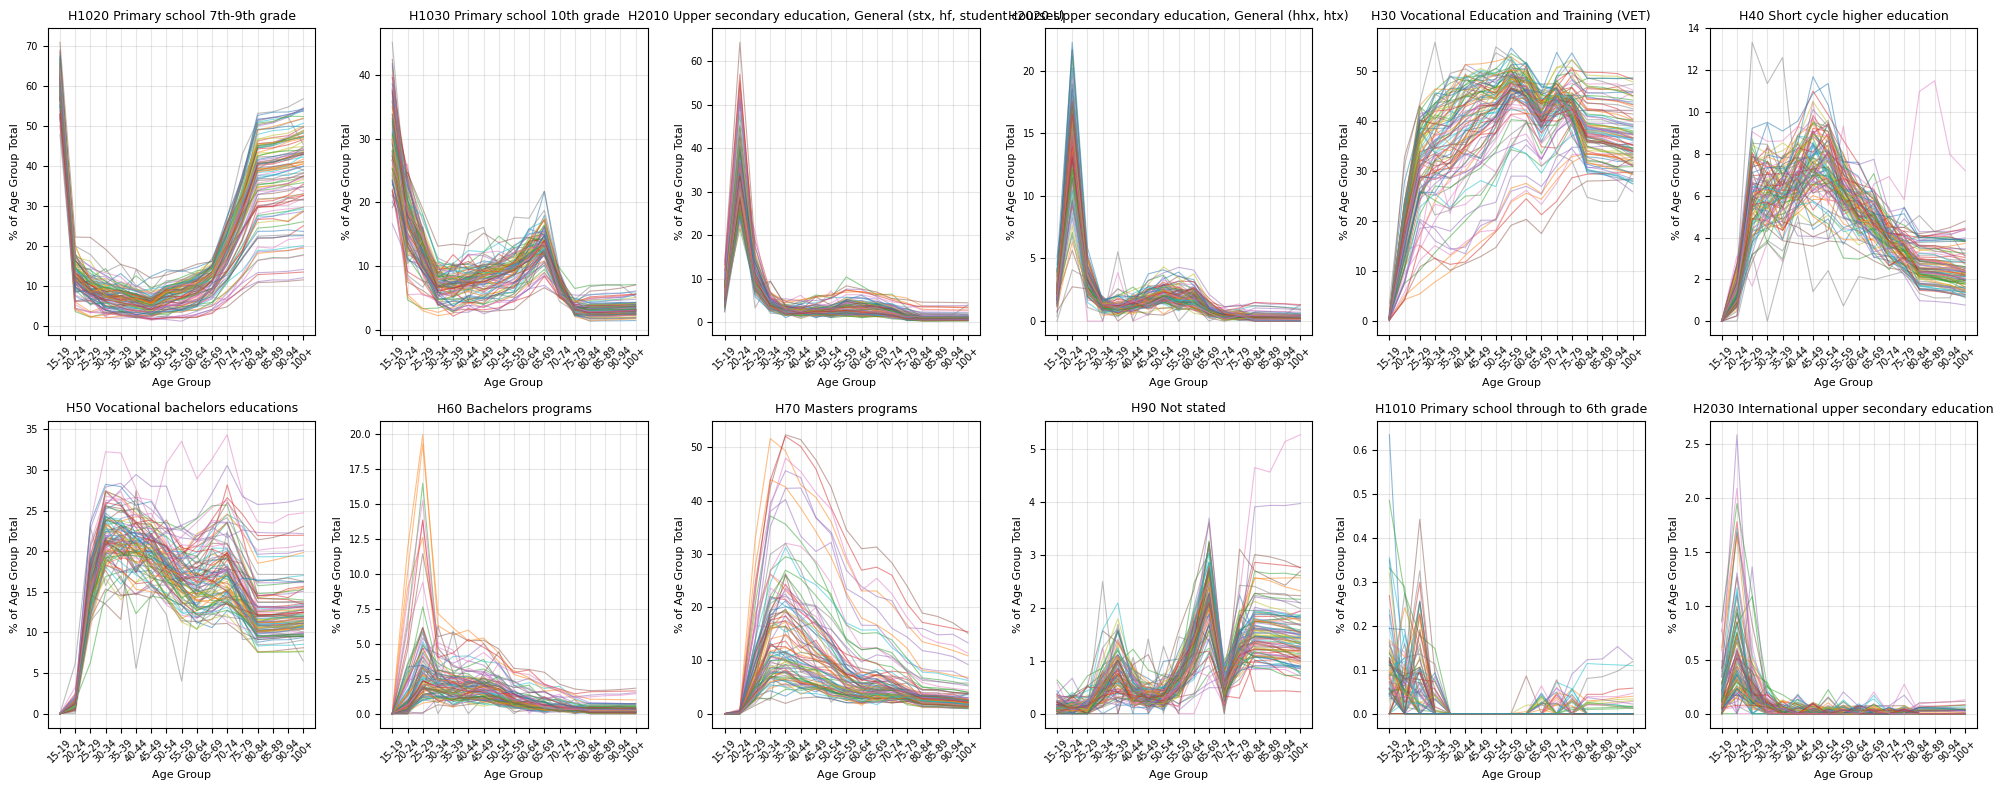

In [275]:
import matplotlib.pyplot as plt

# Get the education totals by municipality, age_group, and education level
edu_by_muni = df_combined.groupby(['municipality', 'age_group', 'education'])['N_edu'].sum().reset_index()

# Get unique education levels (excluding 'No education data')
edu_levels_to_plot = [e for e in edu_by_muni['education'].unique() if e != 'No education data']

# Create figure with subplots
fig, axes = plt.subplots(2, 6, figsize=(20, 8))
axes = axes.flatten()

# Define all age groups including 70+
all_age_groups = ['15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', 
                  '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80-84', 
                  '85-89', '90-94', '100+']

# Plot each education level
for idx, edu_level in enumerate(edu_levels_to_plot[:12]):
    ax = axes[idx]
    
    # Filter data for this education level
    edu_data = edu_by_muni[edu_by_muni['education'] == edu_level]
    
    # Plot each municipality
    for muni in edu_data['municipality'].unique():
        muni_data = edu_data[edu_data['municipality'] == muni]
        
        # Reindex to include all age groups (fill missing with 0)
        muni_data = muni_data.set_index('age_group').reindex(all_age_groups, fill_value=0).reset_index()
        
        # Get total N_edu for each age group in this municipality (across all education levels)
        total_by_age = df_combined[df_combined['municipality'] == muni].groupby('age_group')['N_edu'].sum()
        total_by_age = total_by_age.reindex(all_age_groups, fill_value=0)
        
        # Calculate percentage: N_edu for this education / total N_edu for this age group
        muni_data['pct_N_edu'] = (muni_data['N_edu'] / total_by_age.values) * 100
        muni_data['pct_N_edu'] = muni_data['pct_N_edu'].fillna(0)
        
        ax.plot(muni_data['age_group'], muni_data['pct_N_edu'], alpha=0.5, linewidth=0.8)
    
    # Extract just the education name from the full string
    edu_name =  edu_level
    ax.set_title(edu_name, fontsize=9)
    ax.set_xlabel('Age Group', fontsize=8)
    ax.set_ylabel('% of Age Group Total', fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
df_combined = pd.read_csv('data/combined_population_education.csv')
df_elections = pd.read_csv('data/denmark_election_results_with_turnout.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/combined_population_education.csv'

In [271]:
df_combined.to_csv('data/FOLK1D_HFUDD11_combined.csv')
df_combined.head()


,municipality,gender,age_group,N,education,pct_N,N_edu
0,Aabenraa,Men,100+,30,H30 Vocational Education and Training (VET),0.001847,0.055419
1,Aabenraa,Men,100+,30,H90 Not stated,0.000616,0.018473
2,Aabenraa,Men,100+,30,H1020 Primary school 7th-9th grade,0.364532,10.935961
3,Aabenraa,Men,100+,30,H1030 Primary school 10th grade,0.020936,0.628079
4,Aabenraa,Men,100+,30,"H2010 Upper secondary education, General (stx,...",0.003079,0.092365


In [272]:
print(df_combined['N_edu'].sum())

4491968.999999999


In [276]:
print(len(df_edu.index))

506572


At the moment, this skeleton frame does not contain any data for Greenland or the Faroe Islands. They elect two members each, but their data is not present in the Danish Statbank.

In [ ]:
import pandas as pd
df_edu = pd.read_csv('data/FOLK1D_HFUDD11_combined.csv')


4491968.999999999


In [3]:
print(df_edu['education'].unique())

['H30 Vocational Education and Training (VET)' 'H90 Not stated'
 'H1020 Primary school 7th-9th grade' 'H1030 Primary school 10th grade'
 'H2010 Upper secondary education, General (stx, hf, student courses)'
 'H2020 Upper secondary education, General (hhx, htx)'
 'H40 Short cycle higher education' 'H50 Vocational bachelors educations'
 'H60 Bachelors programs' 'H70 Masters programs'
 'H1010 Primary school through to 6th grade'
 'H2030 International upper secondary education']


In [5]:
# recode H2030 International upper secondary education to H2020 Upper secondary education, General (hhx, htx) and aggregate
df_edu['education'] = df_edu['education'].replace('H2030 International upper secondary education', 'H2020 Upper secondary education, General (hhx, htx)')
df_edu = df_edu.groupby(['municipality', 'gender', 'age_group', 'education'], as_index=False)['N_edu'].sum()

In [12]:
df_edu.to_csv('data/FOLK1D_HFUDD11_combined.csv')
